<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solution to Session 3 - Exercise 0 - A Conv1D Classifier for Genomic Sequences
Genomes are long sequences made up from the characters A, C, G, and T. They contain genes, which are the blueprints for proteins. Genes are made up of exons that are interrupted (by so-called introns). We consider the task of finding the boundariesof genes and exons.


```
   GENE START                                                            GENE END
          |                                                                     |
          v                                                                     v
          +----------+                   +---------------+              +-------+
          |  EXON 1  |-------------------|    EXON 2     |--------------|EXON 3 |
          +----------+                   +---------------+              +-------+
          ^          ^                   ^               ^              ^       ^
          |          |                   |               |              |       |
                exon end             exon start        exon end    exon start 
          
             
```


We train a model to label every nucleotide position in a DNA window with one of five classes:

| label | meaning |
|-------|---------|
| 0 | background |
| 1 | gene start |
| 2 | gene end |
| 3 | exon start |
| 4 | exon end |

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from genome_batch_generator import make_batch_generator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## The Data

Each training example is a short genomic DNA window.  
The input **x** is a one-hot encoded matrix of shape `(4, L)`:  
one row per nucleotide letter (A, C, G, T in that order), one column per position.  
The target **y** is an integer label sequence of shape `(L,)` with values 0–4.

In [2]:
SHARDS_DIR = '../../../data/genome/'
BATCH_SIZE = 64
NUM_CLASSES = 5
L = 100  # fixed window length for shards_short

train_loader = make_batch_generator(SHARDS_DIR, split='train', batch_size=BATCH_SIZE, shuffle=True)

# peek at the first batch
x_batch, y_batch, meta = next(iter(train_loader))
print('x_batch shape:', x_batch.shape)   # (B, 4, L)
print('y_batch shape:', y_batch.shape)   # (B, L)
print('L =', x_batch.shape[2])           # confirm L
print('dtype x:', x_batch.dtype, '  dtype y:', y_batch.dtype)
print('example metadata:', meta['chrom'][0], 'start:', meta['start'][0].item())

x_batch shape: torch.Size([64, 4, 100])
y_batch shape: torch.Size([64, 100])
L = 100
dtype x: torch.float32   dtype y: torch.int64
example metadata: chr10 start: 84188734


In [3]:
# Decode the first sequence: convert one-hot back to nucleotide letters
BASES = ['A', 'C', 'G', 'T']  # channel order
x0 = x_batch[0]              # shape (4, L)
y0 = y_batch[0]              # shape (L,)

base_indices = x0.argmax(dim=0)   # most likely base at each position
seq = ''.join(BASES[i] for i in base_indices[:L].tolist())
labels_str = ''.join(str(int(v)) for v in y0[:L].tolist())

print('sequence:'); print(seq)
print('labels:  '); print(labels_str)
print()
print('label class counts in this window:')
for c in range(NUM_CLASSES):
    print(f'  class {c}: {(y0 == c).sum().item()} positions')

sequence:
TTCAAAATCAGATTTGGGCTCACATGATGGCTCTGTCATACACCCACTTTGTGACATTGGGGAGGTCAGATAACCTCTCAGAACTTCTCCCCATCCATAA
labels:  
0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

label class counts in this window:
  class 0: 100 positions
  class 1: 0 positions
  class 2: 0 positions
  class 3: 0 positions
  class 4: 0 positions


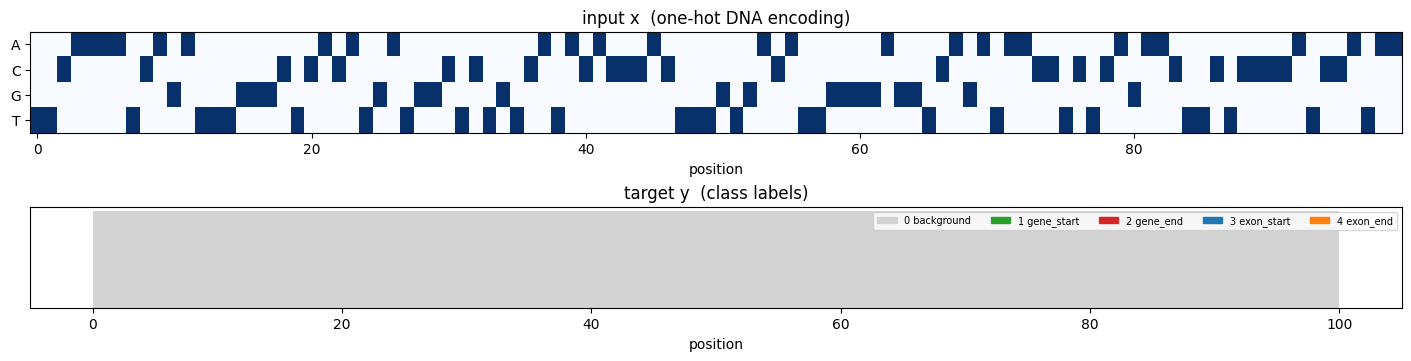

In [4]:
# Visualize the one-hot matrix and the label sequence for the full window
fig, axes = plt.subplots(2, 1, figsize=(14, 3.5), constrained_layout=True)

# top panel: one-hot encoding (4 x L)
ax = axes[0]
ax.imshow(x0[:, :L].numpy(), aspect='auto', interpolation='nearest',
          cmap='Blues', origin='upper')
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(BASES)
ax.set_xlabel('position')
ax.set_title('input x  (one-hot DNA encoding)')

# bottom panel: label sequence
ax = axes[1]
colors = ['lightgrey', 'tab:green', 'tab:red', 'tab:blue', 'tab:orange']
label_names = ['background', 'gene_start', 'gene_end', 'exon_start', 'exon_end']
for pos, lbl in enumerate(y0[:L].numpy()):
    ax.bar(pos, 1, color=colors[lbl], width=1.0, align='edge')
# legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=colors[c], label=f'{c} {label_names[c]}') for c in range(NUM_CLASSES)]
ax.legend(handles=legend_handles, loc='upper right', fontsize=7, ncol=5)
ax.set_yticks([])
ax.set_xlabel('position')
ax.set_title('target y  (class labels)');

## The Model

At first, the model are just five 1-dimensional convolutions — no bias, no hidden layers, no activation function, no pooling.

- **4 input channels** — one per nucleotide letter (A, C, G, T)
- **5 output channels** — one score per class, at every position
- **kernel size 7** — the filter looks at 7 consecutive nucleotides at a time, centered around the position to be labeled
- `padding='same'` — output length equals input length

The weight tensor has shape `[5, 4, 7]` = 140 parameters total.

Forward pass: `x` of shape `(B, 4, L)` → conv → `(B, 5, L)` → transpose → `(B, L, 5)`  
The last dimension holds the five class logits for each position.

In [5]:
conv = nn.Conv1d(
    in_channels=4,
    out_channels=NUM_CLASSES,
    kernel_size=7,
    padding='same',
    bias=False,
).to(device)

print(conv)
total_params = sum(p.numel() for p in conv.parameters())
print(f'trainable parameters: {total_params}')

Conv1d(4, 5, kernel_size=(7,), stride=(1,), padding=same, bias=False)
trainable parameters: 140


## Training

The `train_loader` (definition in separate file) iterates over random batches of labelled windows of the human genome. Windows that only contain background positions are subsampled.
We use weighted cross-entropy loss because the classes are very imbalanced — the background class (0) dominates.
We train for **one epoch** only.

In [6]:
# up-weight the rare signal classes
class_weights = torch.tensor([1.0, 10.0, 10.0, 4.0, 4.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    conv.parameters(),
    lr=0.05, # relatively large, for a simple model and one epoch
    weight_decay=0.0001) # regularization, incentive small absolute values for weights

In [7]:
conv.train()

total_batches = len(train_loader)
print_every = max(1, total_batches // 10)
loss_history = []

for batch_idx, (x, y, _) in enumerate(train_loader, start=1):
    x = x.to(device)   # (B, 4, L)
    y = y.to(device)   # (B, L)

    optimizer.zero_grad()

    logits = conv(x).transpose(1, 2)          # (B, L, 5)
    loss = criterion(logits.reshape(-1, NUM_CLASSES), y.reshape(-1))

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == total_batches:
        print(f'  batch {batch_idx:4d}/{total_batches}  loss={loss.item():.4f}')


  batch    1/486  loss=1.5606
  batch   48/486  loss=0.1457
  batch   96/486  loss=0.1299
  batch  144/486  loss=0.1015
  batch  192/486  loss=0.1071
  batch  240/486  loss=0.0867
  batch  288/486  loss=0.1025
  batch  336/486  loss=0.0971
  batch  384/486  loss=0.0822
  batch  432/486  loss=0.1057
  batch  480/486  loss=0.0851
  batch  486/486  loss=0.0930


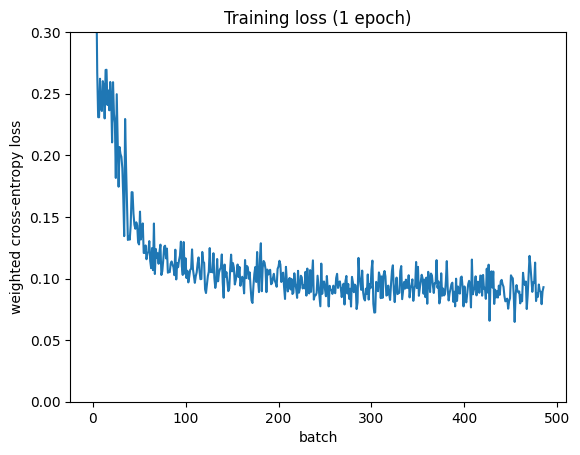

In [8]:
plt.plot(loss_history)
plt.ylim(0, 0.3)
plt.xlabel('batch')
plt.ylabel('weighted cross-entropy loss')
plt.title('Training loss (1 epoch)');

## Inspect the Learned Filter Weights

The weight tensor has shape `[num_classes, in_channels, kernel_size]` = `[5, 4, 7]`.  
Axis 0 selects the class, axis 1 selects the nucleotide (A/C/G/T), axis 2 selects the kernel position.

Each row of the heatmap below shows which nucleotides at which relative positions push the score for that class up (red) or down (blue).

In [9]:
# Print weight summary
weight = conv.weight.detach().cpu()   # [5, 4, 7] = [class, base, kernel_pos]
print(f'weight shape: {tuple(weight.shape)}  # [class, base, kernel_pos]')
print('weight:')
print(weight.numpy().round(3))

weight shape: (5, 4, 7)  # [class, base, kernel_pos]
weight:
[[[ 0.651  0.056  0.896  0.747  1.363  0.909  0.137]
  [ 0.281  0.544  0.766  1.48   1.302  1.245  1.074]
  [ 0.805  0.705  0.382  0.93   0.622  0.215  0.323]
  [ 0.427  0.871  1.145  1.494 -0.047  0.559  1.099]]

 [[ 0.24  -0.936 -0.634  1.398 -1.482 -1.369 -1.157]
  [-0.972  0.197 -0.131 -1.709 -0.903 -1.244 -0.32 ]
  [ 0.163 -0.348 -0.717 -1.796 -1.887  1.361 -0.214]
  [-1.008 -0.52  -0.825 -1.601  1.151 -1.759 -0.626]]

 [[-0.229 -0.664 -0.09  -1.187 -1.435  1.216  0.955]
  [-0.144  0.015 -0.351 -0.046 -1.193 -1.489 -1.389]
  [ 0.132  0.102 -1.04  -0.914 -1.626  0.17   0.01 ]
  [-0.278 -0.066  0.069 -0.613  1.312 -1.848 -1.469]]

 [[-1.513  1.743 -1.828 -1.072  0.138  0.055 -0.363]
  [ 0.289 -1.331 -1.558 -0.909  0.033  0.614  0.457]
  [-2.462 -1.753  1.838 -0.37  -0.587 -0.738 -0.301]
  [ 0.632 -1.732 -1.666 -0.935 -0.656 -0.036  0.52 ]]

 [[ 0.069 -0.325  0.395 -1.746 -1.683 -2.03   0.595]
  [-0.305  0.094 -0.38  -0.848

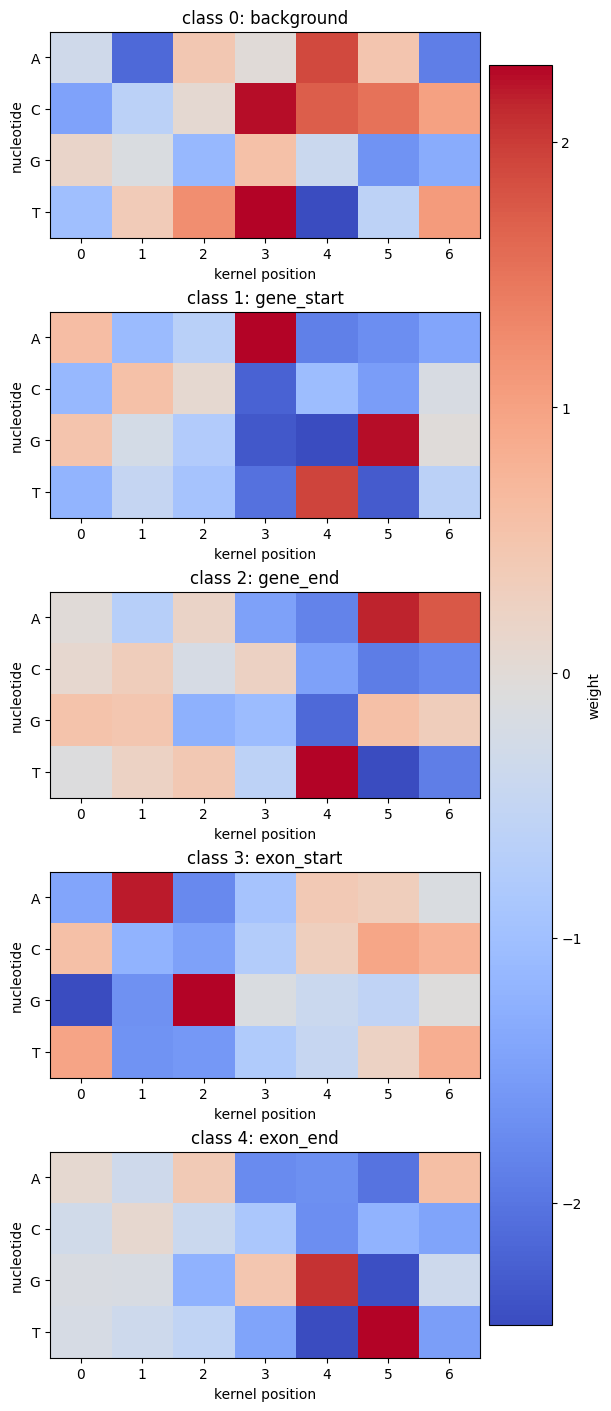

In [10]:
# Plot one heatmap per class
CLASS_NAMES = ['background', 'gene_start', 'gene_end', 'exon_start', 'exon_end']

fig, axes = plt.subplots(NUM_CLASSES, 1, figsize=(6, 2.8 * NUM_CLASSES),
                         squeeze=False, constrained_layout=True)

image = None
for class_idx in range(NUM_CLASSES):
    ax = axes[class_idx, 0]
    image = ax.imshow(
        weight[class_idx].numpy(),   # shape (4, 7)
        aspect='auto',
        interpolation='nearest',
        cmap='coolwarm',
        origin='upper',
    )
    ax.set_title(f'class {class_idx}: {CLASS_NAMES[class_idx]}')
    ax.set_xlabel('kernel position')
    ax.set_ylabel('nucleotide')
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(BASES)

if image is not None:
    fig.colorbar(image, ax=axes, shrink=0.95, label='weight', location='right', pad=0.02)

### YOUR TASK: Interpret the learned filters

- Q1: What character patterns were recognized for exon and gene starts and ends?  
  **Answer:** gene start: ATG, exon start: AG, exon end: GT, gene end: T{A,G}{A,G} = TAA, TAG, TGA, TGG

- Q2: Why could interpretability suffer if we took more channels and then built a (weighted) sum of them to get the class scores?  
  **Answer:** The model could learn to recognize a pattern by adding the results of multiple filters, so that no single filter would be interpretable on its own.

- Q3: Actually, the pattern TGG does not regularly occur at the ends of genes. However, the learned filter for gene ends has a strong positive weight for TGG. Why could this be?  
  **Answer:** This is a consequence of a model error, A and G occurr at positions  5 and 6 around the gene ends, and the model cannot consider combinations of positions with a single filter per class.

- Q4: How could we modify the model to fix this problem?  
  **Answer:** We could add more filters per class. One filter could learn T{A,G}A and one TGA. Or, one filter could learn T{A,G}{A,G} and one filter could learn TGG, and then the model could give a strong positive weight to the first filter and a weak negative weight to the second filter for the gene end class, so that it would recognize TAA/TAG/TGA as gene ends, but not TGG. In any case, many filters are beneficial, also to avoid local optima.


## Improve the Convolutional Neural Network

In above very simple architecture, we sacrificed **accuracy** for interpretability.
Now, build a more complex model by applying one or more of the following modifications:

 1. Add additional convolutional layers with non-linearities in between.
 2. Play with the kernel size.
 3. Increase the receptive field of the model, i.e. the number of input positions that can influence the output at a given position, using dilation.

'Aim at a **validation F1 score of class 3 == "exon end" of at least 0.4**. 

## Conv1D + Multilayer Perceptron

YOUR TASK: Define a sequential neural network architecture with multiple convolutional layers and non-linearities in between.  
Below training code expects output shape `(B, 5, L)`. If your model outputs shape `(B, L, 5)`, then remove the `.transpose(1,2)` in `train_one_epoch()`.  


In [11]:
model = nn.Sequential(
    nn.Conv1d(in_channels=4, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv1d(in_channels=32, out_channels=8, kernel_size=5, dilation=3, padding='same'),
    nn.ReLU(),
    nn.Conv1d(in_channels=8, out_channels=8, kernel_size=5, dilation=3, padding='same'),
    nn.ReLU(),
    nn.Conv1d(in_channels=8, out_channels=NUM_CLASSES, kernel_size=1)
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'trainable parameters: {total_params:,}')

Sequential(
  (0): Conv1d(4, 32, kernel_size=(3,), stride=(1,), padding=same)
  (1): ReLU()
  (2): Conv1d(32, 8, kernel_size=(5,), stride=(1,), padding=same, dilation=(3,))
  (3): ReLU()
  (4): Conv1d(8, 8, kernel_size=(5,), stride=(1,), padding=same, dilation=(3,))
  (5): ReLU()
  (6): Conv1d(8, 5, kernel_size=(1,), stride=(1,))
)
trainable parameters: 2,077


## Training

We reuse the same weighted cross-entropy loss.  
The training loop is extracted into `train_one_epoch` so it can be called for multiple epochs without code repetition.  
We also create a validation loader to track generalisation to new data.

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device, print_every=None):
    """Run one full pass over `loader`, return per-batch loss list."""
    model.train()
    total_batches = len(loader)
    if print_every is None:
        print_every = max(1, total_batches // 10)
    loss_history = []
    for batch_idx, (x, y, _) in enumerate(loader, start=1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x).transpose(1, 2)                        # (B, L, C)
        # average CEE over all positions and batch elements
        loss = criterion(logits.reshape(-1, NUM_CLASSES), y.reshape(-1)) 
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == total_batches:
            print(f'  batch {batch_idx:4d}/{total_batches}  loss={loss.item():.4f}')
    return loss_history


val_loader = make_batch_generator(SHARDS_DIR, split='val', batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
NUM_EPOCHS = 3
all_loss = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n--- epoch {epoch}/{NUM_EPOCHS} ---')
    epoch_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    all_loss.extend(epoch_loss)


--- epoch 1/3 ---
  batch    1/486  loss=1.8001
  batch   48/486  loss=0.2159
  batch   96/486  loss=0.2355
  batch  144/486  loss=0.1971
  batch  192/486  loss=0.1812
  batch  240/486  loss=0.1673
  batch  288/486  loss=0.1431
  batch  336/486  loss=0.1635
  batch  384/486  loss=0.1313
  batch  432/486  loss=0.0996
  batch  480/486  loss=0.1349
  batch  486/486  loss=0.1339

--- epoch 2/3 ---
  batch    1/486  loss=0.1348
  batch   48/486  loss=0.1063
  batch   96/486  loss=0.1120
  batch  144/486  loss=0.1217
  batch  192/486  loss=0.1165
  batch  240/486  loss=0.1064
  batch  288/486  loss=0.1064
  batch  336/486  loss=0.0823
  batch  384/486  loss=0.0940
  batch  432/486  loss=0.0686
  batch  480/486  loss=0.1129
  batch  486/486  loss=0.0832

--- epoch 3/3 ---
  batch    1/486  loss=0.1050
  batch   48/486  loss=0.1075
  batch   96/486  loss=0.0958
  batch  144/486  loss=0.0944
  batch  192/486  loss=0.1059
  batch  240/486  loss=0.0950
  batch  288/486  loss=0.0920
  batch  336/

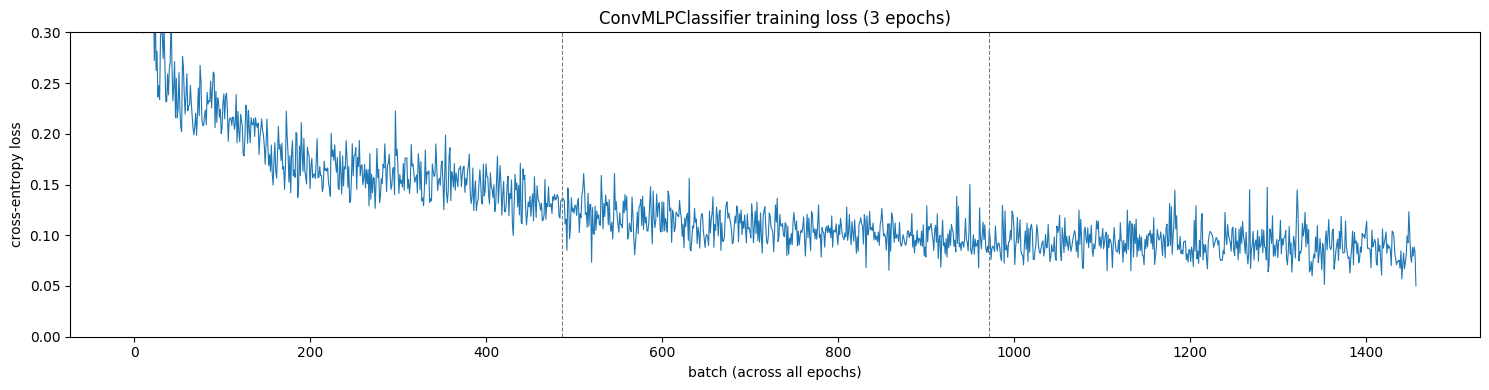

In [14]:
n_per_epoch = len(train_loader)

plt.figure(figsize=(15, 4))
plt.plot(all_loss, linewidth=0.8)
for ep in range(1, NUM_EPOCHS):
    plt.axvline(ep * n_per_epoch, color='grey', linestyle='--', linewidth=0.8)
plt.xlabel('batch (across all epochs)')
plt.ylabel('cross-entropy loss')
plt.title(f'ConvMLPClassifier training loss ({NUM_EPOCHS} epochs)')
plt.ylim(0, 0.3)
plt.tight_layout();

## Validation: F1 Score for Class 3 (exon_end)

We collect predictions over the full validation set and compute precision, recall, and F1 for class 3 directly from true positives (TP), false positives (FP), and false negatives (FN):

$$\text{Precision} = \frac{TP}{TP+FP}, \quad \text{Recall} = \frac{TP}{TP+FN}, \quad F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [15]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y, _ in val_loader:
        logits = model(x.to(device)).transpose(1, 2)  # (B, L, C)
        preds = logits.argmax(dim=-1)                  # (B, L)
        all_preds.append(preds.cpu().reshape(-1))
        all_labels.append(y.reshape(-1))

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# F1 for class 3 (exon_end) computed from TP, FP, FN
c = 3
tp = ((all_preds == c) & (all_labels == c)).sum().item()
fp = ((all_preds == c) & (all_labels != c)).sum().item()
fn = ((all_preds != c) & (all_labels == c)).sum().item()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f'Class {c} (exon_end):')
print(f'  TP={tp}  FP={fp}  FN={fn}')
print(f'  Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}')

Class 3 (exon_end):
  TP=945  FP=1661  FN=366
  Precision=0.363  Recall=0.721  F1=0.483
